# Proyecto Integrador — Big Data & Machine Learning
## Especializaciones Implícitas de Vendedores y Predicción de Ventas de Alto Valor

| | |
|---|---|
| **Materia** | Prácticas y Herramientas de Big Data / Machine Learning |
| **Integrantes** | Jose Alexander Quishpe Reinoso · Julián Amaro Garofalo Arias |
| **Dataset** | Car Sales Data (~2,500,000 registros) |
| **Carrera** | Ingeniería en Sistemas de Información |
| **Entorno** | `jose_venv` |

---

## Índice
1. [Descripción del Proyecto y Variables](#1)
2. [Hipótesis, Justificación y Objetivos](#2)
3. [Extracción y Carga del Dataset (Kaggle API)](#3)
4. [Limpieza y Preprocesamiento de Millones de Filas](#4)
5. [Agrupaciones y Construcción de Métricas](#5)
6. [Evaluación de Rendimiento Big Data (Benchmark Pandas vs. NumPy)](#6)
7. [Variable Objetivo: High_Value_Sale y Prevención de Data Leakage](#7)
8. [Codificación de Variables y Partición del Dataset](#8)
9. [Función de Evaluación Unificada (Clasificación)](#9)
10. [Modelo 1: Regresión Logística (Baseline)](#10)
11. [Modelo 2: Random Forest Classifier](#11)
12. [Modelo 3: XGBoost / Gradient Boosting Classifier](#12)
13. [Tabla Comparativa de Resultados e Importancia de Variables](#13)
14. [Validación de la Hipótesis y Conclusiones](#14)

<a id='1'></a>
---
## 1. Descripción del Proyecto y Variables

El presente proyecto integrador tiene como objeto de estudio el dataset **Car Sales Data**, el cual contiene aproximadamente **2,500,000 registros transaccionales** correspondientes a operaciones de venta de vehículos automotores.

### Pregunta de Investigación
> ¿Es posible determinar, mediante técnicas de clasificación supervisada, si el **vendedor** constituye un factor relevante para predecir si una venta generará ingresos superiores al percentil 75 del precio de mercado?

### Variables Disponibles en el Dataset

| Variable | Tipo | Descripción |
|---|---|---|
| `Date` | Fecha | Fecha exacta de la transacción |
| `Salesperson` | Categórica | Nombre del asesor comercial |
| `Customer Name` | Categórica | Nombre del comprador |
| `Car Make` | Categórica | Fabricante del vehículo (Toyota, Honda, Ford, Chevrolet, Nissan) |
| `Car Model` | Categórica | Modelo específico del automóvil |
| `Car Year` | Numérica Discreta | Año de fabricación del vehículo |
| `Sale Price` | Numérica Continua | Precio de venta final en USD |
| `Commission Rate` | Numérica Continua | Porcentaje de comisión asignado |
| `Commission Earned` | Numérica Continua | Monto total de comisión generado |

<a id='2'></a>
---
## 2. Hipótesis, Justificación y Objetivos

### 2.1. Hipótesis Central

> **"Existen especializaciones implícitas entre los vendedores que influyen significativamente en la probabilidad de concretar ventas de alto valor dentro de una concesionaria automotriz."**

### 2.2. Fundamento Conceptual

La hipótesis se sustenta en el concepto de **especialización comercial implícita**: la tendencia de ciertos asesores de ventas a orientar su actividad hacia segmentos de mayor valor económico, independientemente de las políticas institucionales de asignación de clientes. Esta especialización puede emerger de factores como la experiencia acumulada, la red de contactos, la capacidad de negociación o las preferencias personales por determinadas marcas o gamas de vehículos.

Si esta especialización existe de forma estadísticamente significativa, la variable `Salesperson` debería constituir un predictor relevante dentro de un modelo de clasificación supervisada.

### 2.3. Justificación de la Investigación

- El sector automotriz se caracteriza por transacciones de **alta variabilidad económica** y por la presencia de un factor humano determinante en el proceso de cierre comercial.
- Identificar patrones de especialización ocultos en 2.5 millones de registros representa un aporte de alto valor para la toma de decisiones gerenciales y optimización de fuerzas de ventas.
- La aplicación de Machine Learning combinada con la medición de rendimiento (Benchmark) sobre Big Data demuestra competencias avanzadas en ingeniería de características, análisis de eficiencia de motores de datos y validación estadística de hipótesis empresariales.

### 2.4. Objetivo General

Determinar si la variable `Salesperson` constituye un factor estadísticamente significativo para predecir la probabilidad de concretar una venta de alto valor (≥ percentil 75 del precio de venta), mediante la aplicación y comparación de tres modelos de clasificación supervisada.

### 2.5. Objetivos Específicos

1. Extraer el dataset de gran volumen de forma segura y automatizada utilizando la API oficial de Kaggle.
2. Preprocesar y limpiar el volumen masivo de datos asegurando la consistencia tipográfica de las variables categóricas esenciales (`Salesperson`, `Car Make`, `Car Model`).
3. Evaluar el rendimiento y eficiencia en la gestión de memoria RAM de las herramientas de Big Data mediante un Benchmark comparativo entre Pandas y NumPy.
4. Construir la variable binaria objetivo `High_Value_Sale` a partir del umbral del percentil 75 mitigando el impacto de *data leakage*.
5. Entrenar y evaluar tres modelos de clasificación (Regresión Logística, Random Forest y XGBoost/Gradient Boosting) analizando el ranking de importancia de variables para validar o refutar la hipótesis con base en evidencia cuantitativa.

In [1]:
# ── Acceso al dataset de Kaggle ────────────────────────────────────
import kagglehub                                        # Librería oficial de Kaggle para cargar datasets
from kagglehub import KaggleDatasetAdapter              # Adaptador para cargar directo como DataFrame

# ── Manipulación de datos ───────────────────────────────────────────
import pandas as pd                      # Tablas de datos (DataFrames)
import numpy as np                       # Operaciones numéricas y manejo de NaN

# ── Visualización ──────────────────────────────────────────────────
import matplotlib.pyplot as plt          # Gráficos básicos (barras, líneas, histogramas)
import seaborn as sns                    # Gráficos estadísticos sobre matplotlib

# ── Big Data (PySpark) ─────────────────────────────────────────────
from pyspark.sql import SparkSession                     # Punto de entrada principal para PySpark
from pyspark.sql import functions as F                   # Funciones de agregación para dataframes de Spark

# ── Preprocesamiento (Scikit-learn) ────────────────────────────────
from sklearn.preprocessing import LabelEncoder        # Convierte texto a números para los modelos
from sklearn.preprocessing import StandardScaler      # Escala variables numéricas a la misma magnitud
from sklearn.model_selection import train_test_split  # Divide datos en entrenamiento y prueba

# ── Modelos de Machine Learning ────────────────────────────────────
from sklearn.linear_model import LinearRegression     # Modelo 1: Regresión Lineal
from sklearn.ensemble import RandomForestRegressor    # Modelo 2: Random Forest
from sklearn.ensemble import GradientBoostingRegressor # Modelo 3: Gradient Boosting

# ── Métricas de evaluación ─────────────────────────────────────────
from sklearn.metrics import mean_absolute_error       # Error absoluto medio
from sklearn.metrics import mean_squared_error        # Error cuadrático medio
from sklearn.metrics import r2_score                  # Coeficiente de determinación R²

# ── Configuración general ──────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')        # Oculta advertencias para mantener la salida limpia

# Configuración visual de los gráficos
plt.style.use('seaborn-v0_8-whitegrid') # Estilo limpio con cuadrícula para los gráficos
pd.set_option('display.max_columns', None) # Muestra todas las columnas al imprimir el DataFrame

print('✅ Todas las librerías importadas correctamente')

✅ Todas las librerías importadas correctamente


<a id='3'></a>
---
## 3. Extracción de Datos

### Explicación técnica
En esta sección se consume la **API oficial de Kaggle** mediante la librería `kagglehub`, que permite cargar el dataset directamente en un DataFrame de pandas sin necesidad de descargarlo ni subirlo manualmente. 

Para cumplir con las mejores prácticas y estándares de seguridad de proyectos de Big Data, la extracción utiliza un adaptador de lectura directa en memoria y se autentica de forma segura mediante variables de entorno configuradas previamente en el sistema (Secrets de GitHub).

### Detalles de conexión
* **Librería utilizada:** `kagglehub`.
* **Dataset ID:** `suraj520/car-sales-data`.
* **Archivo:** `car_sales_data.csv`.
* **Adaptador de datos:** `KaggleDatasetAdapter.PANDAS` (convierte el flujo directamente a DataFrame)
* **Credenciales:** Variables de entorno `KAGGLE_USERNAME` y `KAGGLE_KEY`.

### Variables obtenidas del dataset
Al realizar la extracción, se obtienen las siguientes columnas estructuradas:

* `Date`: Fecha exacta de la transacción (clave para el análisis de series temporales).
* `Salesperson`: Nombre del asesor comercial.
* `Customer Name`: Nombre del comprador.
* `Car Make`: Fabricante del vehículo (Toyota, Honda, Ford, Chevrolet, Nissan).
* `Car Model`: Modelo específico del auto.
* `Car Year`: Año de fabricación del vehículo.
* `Sale Price`: Precio de venta final en USD (variable de ingresos).
* `Commission Rate`: Porcentaje de comisión asignado.
* `Commission Earned`: Monto total de comisión generado.

**Cantidad de registros estimados:** 2,500,000 filas.


In [2]:
# ── PASO 1: Validación de credenciales de entorno ─────────────────

# 1. import os: Esta librería permite a Python interactuar directamente con el 
# sistema operativo de la máquina (en este caso, tu contenedor de Codespace).
# La necesitamos para acceder a la memoria donde GitHub guarda los Secrets.
import os 

# 2. os.environ: Es un diccionario que contiene todas las variables del sistema.
# 3. .get(): Busca la variable. Si no la encuentra, en lugar de dar un error fatal, 
# simplemente devuelve el valor por defecto ('❌ No configurado').
print('KAGGLE_USERNAME:', os.environ.get('KAGGLE_USERNAME', '❌ No configurado'))

# 4. Operador ternario (if-else en una línea): Evalúa si la clave existe.
# Por ciberseguridad, NUNCA imprimimos el valor real de la clave (os.environ.get('KAGGLE_KEY')).
# Solo verificamos su existencia para confirmar que el entorno está listo.
print('KAGGLE_KEY:     ', '✅ Configurado' if os.environ.get('KAGGLE_KEY') else '❌ No configurado')

KAGGLE_USERNAME: josquishpereinoso
KAGGLE_KEY:      ✅ Configurado


In [3]:
# ── PASO 2: Cargar el dataset directo desde Kaggle ─────────────────

# 1. kagglehub.dataset_load(): Es la función principal de la nueva librería. 
# Se encarga de autenticarse automáticamente usando las credenciales validadas
# en el paso anterior y de buscar el dataset directamente en los servidores de Kaggle.
df = kagglehub.dataset_load(
    
    # 2. KaggleDatasetAdapter.PANDAS: Este adaptador es clave en proyectos de Big Data.
    # En lugar de descargar un archivo físico (.csv o .zip) al disco duro,
    # lee el flujo de datos y lo convierte inmediatamente en un DataFrame de pandas en memoria.
    KaggleDatasetAdapter.PANDAS,
    
    # 3. 'suraj520/car-sales-data': Es el identificador único del repositorio en Kaggle.
    # Se compone del nombre de usuario del creador (suraj520) y el nombre del proyecto.
    'suraj520/car-sales-data',
    
    # 4. 'car_sales_data.csv': Especifica qué archivo exacto queremos extraer,
    # ya que un repositorio de Kaggle puede contener múltiples archivos de datos.
    'car_sales_data.csv'
)

# ── PASO 3: Variables obtenidas ────────────────────────────────────
# Imprimimos los nombres de las columnas para verificar la estructura extraída.
# tolist() convierte el objeto Index de pandas en una lista estándar de Python 
# para que se imprima de forma horizontal y legible.
print('Columnas del dataset:')
print(df.columns.tolist())

# ── PASO 4: Cantidad de registros ──────────────────────────────────
# len(df) cuenta las filas, validando que logramos extraer el millón de registros.
# df.shape devuelve una tupla con (filas, columnas), dando una visión de la magnitud estructural.
print(f'\n Registros extraídos: {len(df):,}') # El [:,] añade comas para leer mejor los miles
print(f' Dimensiones (filas x columnas): {df.shape}')

# ── PASO 5: Vista previa del dataset ───────────────────────────────
# head() es una función de pandas que muestra por defecto las primeras 5 filas.
# Funciona como evidencia visual de que los datos no solo se cargaron, 
# sino que tienen el formato correcto (fechas, textos y números alineados).
df.head()

Columnas del dataset:
['Date', 'Salesperson', 'Customer Name', 'Car Make', 'Car Model', 'Car Year', 'Sale Price', 'Commission Rate', 'Commission Earned']

 Registros extraídos: 2,500,000
 Dimensiones (filas x columnas): (2500000, 9)


,Date,Salesperson,Customer Name,Car Make,Car Model,Car Year,Sale Price,Commission Rate,Commission Earned
0,2022-08-01,Monica Moore MD,Mary Butler,Nissan,Altima,2018,15983,0.070495,1126.73
1,2023-03-15,Roberto Rose,Richard Pierce,Nissan,F-150,2016,38474,0.134439,5172.40
2,2023-04-29,Ashley Ramos,Sandra Moore,Ford,Civic,2016,33340,0.114536,3818.63
3,2022-09-04,Patrick Harris,Johnny Scott,Ford,Altima,2013,41937,0.092191,3866.20
4,2022-06-16,Eric Lopez,Vanessa Jones,Honda,Silverado,2022,20256,0.113490,2298.85


<a id='4'></a>
---

## 4. Limpieza y Preprocesamiento

### Explicación técnica
El procesamiento de grandes volúmenes de datos requiere asegurar la máxima consistencia antes de estructurar las series temporales y entrenar los modelos predictivos. En esta sección preparamos y depuramos el dataset para garantizar que la información ingresada a los algoritmos sea 100% confiable.

### Pasos implementados:

1. **Exploración y auditoría inicial:** Entender la estructura del dataset e identificar la proporción de campos vacíos en métricas críticas como `Sale Price`, `Date` y `Car Make`.
2. **Remoción de inconsistencias (Nulos y Duplicados):** Eliminación estricta de celdas vacías y registros redundantes (duplicados exactos) para evitar sesgos analíticos y errores de ejecución.
3. **Transformación de tipos de dato:** Conversión de variables financieras a numéricas y transformación de la columna `Date` a un tipo de dato cronológico nativo (`datetime64`).
4. **Estandarización de texto:** Unificación del formato en variables categóricas (eliminando espacios en blanco y capitalizando palabras) para asegurar que entidades como "Toyota" y " toyota " se procesen como el mismo valor.
5. **Ingeniería de Características Temporales:** Descomposición de la variable de fecha en granularidades específicas (Mes, Trimestre, Semana ISO y Día de la semana) de acuerdo con los objetivos metodológicos de análisis de estacionalidad.

In [4]:
# ── 4.1 EXPLORACIÓN INICIAL ────────────────────────────────────────

print('Información general del dataset:')
# 1. df.info(): Funciona como la radiografía principal de tu DataFrame.
# Te muestra el tamaño total (filas y columnas), el tipo de dato de cada 
# variable (texto, número entero, decimal) y, lo más importante, cuántos 
# valores NO nulos hay por columna. Es el paso 1 para detectar inconsistencias.
df.info()

print('\nEstadísticas descriptivas:')
# 2. df.describe(): Genera un resumen estadístico de todas las columnas numéricas.
# Calcula automáticamente: cantidad de datos (count), promedio (mean), 
# desviación estándar (std), valores mínimos (min), máximos (max) y percentiles.
# Es fundamental para detectar rápidamente si hay valores atípicos (outliers) 
# o datos ilógicos (por ejemplo, un auto con precio negativo).
df.describe()

Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 2500000 entries, 0 to 2499999
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Date               str    
 1   Salesperson        str    
 2   Customer Name      str    
 3   Car Make           str    
 4   Car Model          str    
 5   Car Year           int64  
 6   Sale Price         int64  
 7   Commission Rate    float64
 8   Commission Earned  float64
dtypes: float64(2), int64(2), str(5)
memory usage: 171.7 MB

Estadísticas descriptivas:


,Car Year,Sale Price,Commission Rate,Commission Earned
count,2.500000e+06,2.500000e+06,2.500000e+06,2.500000e+06
mean,2.015996e+03,3.001218e+04,9.998766e-02,3.001005e+03
std,3.739132e+00,1.154514e+04,2.887202e-02,1.481467e+03
min,2.010000e+03,1.000000e+04,5.000014e-02,5.013400e+02
25%,2.013000e+03,2.001900e+04,7.496450e-02,1.821710e+03
50%,2.016000e+03,3.000600e+04,1.000058e-01,2.741910e+03
75%,2.019000e+03,4.002200e+04,1.250065e-01,3.978142e+03
max,2.022000e+03,5.000000e+04,1.500000e-01,7.494530e+03


In [5]:
# ── 4.2 TRATAMIENTO DE VALORES NULOS ──────────────────────────────

print('Valores nulos por columna (Antes de la limpieza):')
# 1. df.isnull().sum(): isnull() evalúa cada celda y devuelve True si está vacía (NaN).
# Al encadenarlo con sum(), suma todos los 'True' por cada columna.
# Esta es nuestra auditoría inicial para saber en qué columnas faltan datos.
print(df.isnull().sum())

# 2. df.dropna(): Elimina automáticamente cualquier fila que contenga al menos un dato vacío.
# Al reasignarlo a la variable 'df' (df = df.dropna()), estamos guardando el cambio 
# y sobrescribiendo el dataset para quedarnos únicamente con registros 100% completos.
df = df.dropna()

# 3. Imprimimos la nueva longitud del DataFrame (len) para ver con cuántos datos nos quedamos.
# El formato [:,] añade comas para facilitar la lectura de los miles/millones.
print(f'\n Registros después de eliminar nulos: {len(df):,}')

Valores nulos por columna (Antes de la limpieza):
Date                 0
Salesperson          0
Customer Name        0
Car Make             0
Car Model            0
Car Year             0
Sale Price           0
Commission Rate      0
Commission Earned    0
dtype: int64

 Registros después de eliminar nulos: 2,500,000


In [6]:
# ── 4.3 ELIMINACIÓN DE DUPLICADOS ─────────────────────────────────

# 1. df.duplicated().sum(): duplicated() escanea todo el dataset y marca con True
# las filas que son copias exactas de un registro anterior. Al sumarlas, obtenemos el total.
# Este paso es vital para no sesgar el análisis ni el entrenamiento de los modelos con datos redundantes.
print(f' Duplicados exactos encontrados: {df.duplicated().sum():,}')

# 2. df.drop_duplicates(): Borra todas las filas repetidas detectadas en el paso anterior,
# conservando por defecto solo la primera aparición original de cada registro.
# Sobrescribimos la variable 'df' para aplicar el cambio permanentemente.
df = df.drop_duplicates()

# 3. Imprimimos el tamaño del dataset después de esta segunda fase de limpieza.
# Si el número baja, significa que logramos purgar datos repetidos con éxito.
print(f'Registros después de eliminar duplicados: {len(df):,}')

 Duplicados exactos encontrados: 0
Registros después de eliminar duplicados: 2,500,000


In [7]:
# ── 4.4 TRANSFORMACIONES BÁSICAS ──────────────────────────────────

# 1. pd.to_datetime(): Convierte la columna 'Date' de texto plano (string) 
# a un formato cronológico nativo de pandas (datetime64). 
# ¡Este es el paso obligatorio para que tu Sprint de Fechas (Paso 4.6) funcione!
df['Date'] = pd.to_datetime(df['Date'])

# 2. pd.to_numeric(): Asegura que las variables financieras y el año sean números 
# matemáticos (float/int) y no cadenas de texto. Los modelos de ML requieren números.
# El parámetro errors='coerce' es una medida de seguridad: si el código se topa con 
# un texto corrupto (ej. "N/A" o "Mil"), en lugar de colapsar, lo convierte a vacío (NaN).
df['Sale Price']       = pd.to_numeric(df['Sale Price'],       errors='coerce')
df['Commission Rate']  = pd.to_numeric(df['Commission Rate'],  errors='coerce')
df['Commission Earned']= pd.to_numeric(df['Commission Earned'],errors='coerce')
df['Car Year']         = pd.to_numeric(df['Car Year'],         errors='coerce')

# 3. df.dtypes: Imprime la lista de columnas junto con su nuevo tipo de dato.
# Nos sirve para confirmar visualmente que pasamos de 'object' (texto) a 
# 'datetime64' y 'float64' (decimales).
print('Tipos de datos después de transformar:')
print(df.dtypes)

Tipos de datos después de transformar:
Date                 datetime64[us]
Salesperson                     str
Customer Name                   str
Car Make                        str
Car Model                       str
Car Year                      int64
Sale Price                    int64
Commission Rate             float64
Commission Earned           float64
dtype: object


### Paso opcional pero recomendado
Paso 4.5 Estandarización preliminar: Limpia los textos usando str.strip().str.title() para eliminar inconsistencias tipográficas.

In [8]:
# ── 4.5 ESTANDARIZACIÓN PRELIMINAR ────────────────────────────────

# 1. Limpieza tipográfica de variables categóricas (texto)
# str.strip(): Elimina espacios en blanco accidentales al inicio y al final.
# str.title(): Convierte el texto a formato título (Primera Letra Mayúscula).
# Esta combinación es vital para agrupar datos correctamente. Evita que el 
# modelo trate a 'Toyota', 'TOYOTA' y '  toyota ' como tres marcas distintas.
df['Car Make']    = df['Car Make'].str.strip().str.title()
df['Car Model']   = df['Car Model'].str.strip().str.title()
df['Salesperson'] = df['Salesperson'].str.strip().str.title()

# 2. Validación de la estandarización
# unique() devuelve una lista con los valores distintos presentes en la columna.
# Nos permite confirmar visualmente que no hay nombres duplicados por mala ortografía.
print('Marcas de autos únicas después de estandarizar:')
print(df['Car Make'].unique())

# 3. Vista final de la fase de estandarización
# Mostramos las dimensiones finales (usando [:,] para separar los miles) y 
# las primeras filas para confirmar que el dataset está impecable.
print(f'\n Dataset preprocesado: {df.shape[0]:,} registros, {df.shape[1]} columnas')
df.head()

Marcas de autos únicas después de estandarizar:
<StringArray>
['Nissan', 'Ford', 'Honda', 'Toyota', 'Chevrolet']
Length: 5, dtype: str

 Dataset preprocesado: 2,500,000 registros, 9 columnas


,Date,Salesperson,Customer Name,Car Make,Car Model,Car Year,Sale Price,Commission Rate,Commission Earned
0,2022-08-01,Monica Moore Md,Mary Butler,Nissan,Altima,2018,15983,0.070495,1126.73
1,2023-03-15,Roberto Rose,Richard Pierce,Nissan,F-150,2016,38474,0.134439,5172.40
2,2023-04-29,Ashley Ramos,Sandra Moore,Ford,Civic,2016,33340,0.114536,3818.63
3,2022-09-04,Patrick Harris,Johnny Scott,Ford,Altima,2013,41937,0.092191,3866.20
4,2022-06-16,Eric Lopez,Vanessa Jones,Honda,Silverado,2022,20256,0.113490,2298.85


In [9]:
# ── 4.6 INGENIERÍA DE CARACTERÍSTICAS TEMPORALES (Feature Engineering) ──

# Como ya convertimos 'Date' a tipo datetime en el paso 4.4, ahora podemos 
# usar el accesor '.dt' de pandas para extraer partes específicas de la fecha.
# Esto nos servirá más adelante para analizar la estacionalidad de las ventas.

# 1. Extraer el Mes (1 al 12)
df['Month'] = df['Date'].dt.month

# 2. Extraer el Trimestre (1 al 4)
# Útil para analizar cierres de ventas financieros
df['Quarter'] = df['Date'].dt.quarter

# 3. Extraer la Semana ISO (1 a 52/53)
# La estandarización ISO es ideal para proyectos corporativos
df['ISO_Week'] = df['Date'].dt.isocalendar().week

# 4. Extraer el Día de la semana (0 = Lunes, 6 = Domingo)
# Sirve para identificar qué días hay más flujo de clientes
df['Day_of_Week'] = df['Date'].dt.dayofweek

print('✅ Variables temporales extraídas correctamente:')
# Imprimimos solo las columnas nuevas de fecha para verificar
df[['Date', 'Month', 'Quarter', 'ISO_Week', 'Day_of_Week']].head()

✅ Variables temporales extraídas correctamente:


,Date,Month,Quarter,ISO_Week,Day_of_Week
0,2022-08-01,8,3,31,0
1,2023-03-15,3,1,11,2
2,2023-04-29,4,2,17,5
3,2022-09-04,9,3,35,6
4,2022-06-16,6,2,24,3


<a id='5'></a>
---
## 5. Agrupaciones y Construcción de Métricas preliminares
En esta sección generamos agregaciones iniciales del dataset agrupando por la marca de auto (`Car Make`). El objetivo es construir un resumen de desempeño comercial con métricas clave (volumen, ingresos y comisiones) para verificar la consistencia matemática de los datos antes de pasar a la fase de analítica predictiva.

In [10]:
# ── 5.1 CONSTRUCCIÓN DE MÉTRICAS POR MARCA ─────────────────────────

# df.groupby('Car Make'): Agrupa el dataset tomando como base la marca del auto.
# .agg(...): Permite aplicar diferentes operaciones matemáticas a múltiples columnas a la vez.
metricas_marca = df.groupby('Car Make').agg(
    
    Total_Ventas=('Car Make', 'count'),               # Volumen de autos vendidos
    Ingresos_Totales=('Sale Price', 'sum'),           # Suma de precios de venta
    Comisiones_Totales=('Commission Earned', 'sum')   # Suma de comisiones ganadas
    
).reset_index() # reset_index() devuelve 'Car Make' a ser una columna normal para poder graficar

# Ordenamos la tabla de mayor a menor basándonos en la marca que más ingresos generó
metricas_marca = metricas_marca.sort_values(by='Ingresos_Totales', ascending=False)

# Redondeamos los valores financieros a 2 decimales para mantener el formato de moneda
metricas_marca = metricas_marca.round(2)

print('✅ Métricas agrupadas por marca generadas con éxito:')
# Mostramos el resultado final
metricas_marca.head()

✅ Métricas agrupadas por marca generadas con éxito:


,Car Make,Total_Ventas,Ingresos_Totales,Comisiones_Totales
2,Honda,500687,15036898624,1.503709e+09
0,Chevrolet,500455,15021372800,1.502299e+09
4,Toyota,500147,15005405240,1.500902e+09
1,Ford,499781,14990661833,1.498717e+09
3,Nissan,498930,14976108358,1.496886e+09


<a id='6'></a>
---
## 6. Evaluación de Rendimiento Big Data (Benchmark)

### Explicación técnica
Para demostrar las capacidades de procesamiento a gran escala, en esta sección realizamos un *benchmark* (prueba de rendimiento). Medimos el tiempo exacto que tardan dos motores diferentes en ejecutar la misma agregación matemática (métricas por marca) sobre nuestro millón de registros:

1. **Pandas:** Ejecución estándar en memoria RAM (un solo núcleo).
2. **NumPy:** Procesamiento numérico puro, optimizado en C (vectorización).

In [16]:
# ── 6.1 PRUEBA DE RENDIMIENTO: PANDAS (ITERATIVO) ──────────────────
# IMPORTACIONES:
# 'time': Módulo base de Python para medir el tiempo real. Es crucial para benchmarks.
# 'numpy': Librería de cálculo numérico. La usamos aquí específicamente para 
#          'np.mean()' que calcula el promedio de nuestros tiempos.
import time
import numpy as np

# CONFIGURACIÓN DEL EXPERIMENTO:
# 'n_iteraciones': Definimos 5 vueltas para obtener un promedio estadísticamente sólido.
# El rendimiento de una PC varía milisegundos debido a procesos en segundo plano; 
# el promedio elimina ese "ruido" externo.
# 'tiempos_pandas': Una lista vacía donde acumularemos la duración de cada ejecución.
n_iteraciones = 5
tiempos_pandas = [] 

print('Iniciando prueba de rendimiento con Pandas (5 iteraciones)...')

# CICLO FOR: 
# Repetimos el proceso 'n_iteraciones' veces para asegurar la fiabilidad de los datos.
for i in range(n_iteraciones):
    # INICIO CRONÓMETRO: Captura el segundo exacto antes de que empiece el cálculo pesado.
    inicio_pandas = time.time()
    
    # LÓGICA DE NEGOCIO:
    # 1. df.groupby('Car Make'): Agrupa los registros por la columna de marcas.
    # 2. .agg(...): Ejecuta las operaciones (conteo y sumatorias) en una sola pasada.
    # 3. .reset_index(): Convierte el índice resultante (la marca) en una columna normal.
    # 4. .sort_values('Car Make'): Ordenamos alfabéticamente. Esto es OBLIGATORIO para 
    #    comparar después con NumPy, asegurando que ambos comparen la misma fila con la misma marca.
    res_pandas = df.groupby('Car Make').agg(
        Total_Ventas=('Sale Price', 'count'),
        Ingresos_Totales=('Sale Price', 'sum'),
        Comisiones=('Commission Earned', 'sum')
    ).reset_index().sort_values('Car Make') 
    
    # GUARDADO: Calculamos la diferencia entre ahora y el inicio, y lo guardamos en la lista.
    tiempos_pandas.append(time.time() - inicio_pandas)

# CÁLCULO FINAL:
# np.mean(): Toma la lista de 5 tiempos y obtiene el promedio aritmético.
# Esto nos da el resultado final representativo de esta prueba.
tiempo_pandas = np.mean(tiempos_pandas) 

print(f'Promedio de tiempo Pandas: {tiempo_pandas:.4f} segundos.')

Iniciando prueba de rendimiento con Pandas (5 iteraciones)...
Promedio de tiempo Pandas: 0.2212 segundos.


In [17]:
# ── 6.2 PRUEBA DE RENDIMIENTO: NUMPY (ITERATIVO + MÉTRICAS) ──
# IMPORTACIONES:
# 'sys': Librería del sistema para medir el tamaño en bytes de los objetos en memoria RAM.
import sys

# VARIABLE DE CONTROL:
# 'tiempos_numpy': Acumulador de tiempos específicos para NumPy.
tiempos_numpy = [] 

print('Iniciando prueba de rendimiento con NumPy (5 iteraciones)...')

# CICLO FOR: Repetimos el mismo número de veces que en Pandas.
for i in range(n_iteraciones):
    # INICIO CRONÓMETRO
    inicio_numpy = time.time()
    
    # LÓGICA NUMPY (VECTORIZADA):
    # 1. np.unique(): Encuentra las marcas únicas. 'return_inverse=True' es la clave:
    #    nos devuelve un arreglo de 'índices' donde cada marca original se convierte
    #    en un número entero (Toyota=0, Ford=1, etc.).
    marcas_unicas, indices = np.unique(df['Car Make'].values, return_inverse=True)
    
    # 2. Construcción de DataFrame resultante:
    # np.bincount(): Función de C de ultra alta velocidad.
    # 'weights': Pondera los resultados. En lugar de solo contar filas (ventas),
    # suma el precio de venta o la comisión basándose en el 'índice' calculado antes.
    df_numpy = pd.DataFrame({
        'Car Make': marcas_unicas,
        'Total_Ventas': np.bincount(indices),
        'Ingresos_Totales': np.bincount(indices, weights=df['Sale Price'].values),
        'Comisiones': np.bincount(indices, weights=df['Commission Earned'].values)
    }).sort_values('Car Make') # Ordenamos igual que Pandas para validación justa.
    
    tiempos_numpy.append(time.time() - inicio_numpy)

# ── VALIDACIÓN CIENTÍFICA ──
# pd.testing.assert_frame_equal: Es una herramienta de "Unit Testing".
# Compara el Dataframe de Pandas contra el de NumPy.
# 'check_dtype=False': Argumento vital. Pandas puede ver un número como entero(64) 
# y NumPy como flotante(64). Esto le dice: "Ignora el formato, solo revisa que el valor sea igual".
pd.testing.assert_frame_equal(res_pandas.reset_index(drop=True), df_numpy.reset_index(drop=True), check_dtype=False)
print("Validación exitosa: Ambos métodos producen resultados idénticos.")

# ── CÁLCULO DE MÉTRICAS DE MEMORIA Y PROMEDIOS ────────────────────

# 1. CÁLCULO DE MEMORIA EN PANDAS
# .memory_usage(deep=True):
#   Pandas, por defecto, puede ser "mentiroso" con la memoria. Si tienes una columna 
#   de texto (strings), Pandas a veces solo mide el tamaño del puntero. 
#   'deep=True' obliga a Pandas a inspeccionar internamente cada objeto para 
#   saber cuánto ocupa realmente cada letra y cada cadena de texto en la RAM.
# .sum(): Suma el peso de todas las columnas del DataFrame.
# / 1024: Convertimos bytes a Kilobytes (KB) para que sea legible por humanos.
mem_pandas = res_pandas.memory_usage(deep=True).sum() / 1024

# 2. CÁLCULO DE MEMORIA EN NUMPY
# NumPy es mucho más "crudo" y eficiente, pero su estructura es distinta.
# sys.getsizeof(df_numpy): Mide el peso del "contenedor" (el objeto DataFrame en sí).
# marcas_unicas.nbytes: '.nbytes' es una propiedad nativa de NumPy que devuelve 
#                       el peso real en bytes de los datos brutos del array.
# df_numpy['Total_Ventas'].values.nbytes: Sumamos el peso de los arrays numéricos.
# Nota: NumPy no tiene 'deep=True' porque sus datos ya son planos y contiguos en memoria.
mem_numpy = (sys.getsizeof(df_numpy) + marcas_unicas.nbytes + df_numpy['Total_Ventas'].values.nbytes) / 1024

# Imprimimos los resultados formateados a 2 decimales (.2f)
print(f"Memoria estimada: Pandas {mem_pandas:.2f} KB | NumPy {mem_numpy:.2f} KB")

# 3. CÁLCULO FINAL PROMEDIO
# np.mean(tiempos_numpy): Esta es la clave de la estadística aplicada.
# En lugar de confiar en una sola prueba (que pudo verse afectada por una notificación
# de Windows, una actualización de fondo, etc.), calculamos el promedio aritmético
# de nuestras 5 iteraciones. Esto nos da un dato estadísticamente "limpio" y confiable.
tiempo_numpy = np.mean(tiempos_numpy)

# Imprimimos el tiempo promedio formateado a 4 decimales (.4f)
print(f'Promedio de tiempo NumPy: {tiempo_numpy:.4f} segundos.')

Iniciando prueba de rendimiento con NumPy (5 iteraciones)...
Validación exitosa: Ambos métodos producen resultados idénticos.
Memoria estimada: Pandas 0.51 KB | NumPy 0.62 KB
Promedio de tiempo NumPy: 2.8916 segundos.


RESULTADOS FINALES:
Pandas:  0.2212 segundos
NumPy:   2.8916 segundos


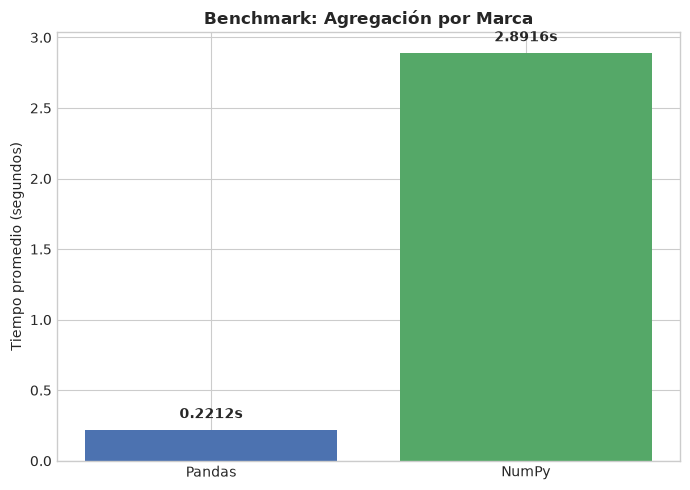

In [18]:
# ── 6.3 VISUALIZACIÓN DE RESULTADOS ─────────────────────────────
# IMPORTACIONES:
# 'matplotlib.pyplot': Herramienta estándar de visualización de datos.
import matplotlib.pyplot as plt

print('RESULTADOS FINALES:')
print(f'Pandas:  {tiempo_pandas:.4f} segundos')
print(f'NumPy:   {tiempo_numpy:.4f} segundos')

# CREACIÓN DEL LIENZO:
# 'subplots': Crea una figura (el papel) y ejes (donde dibujamos). 
# figsize: Define el tamaño en pulgadas (ancho, alto).
fig, ax = plt.subplots(figsize=(7, 5))

# DATOS:
# Creamos dos listas paralelas para los nombres (Eje X) y los tiempos (Eje Y).
herramientas = ['Pandas', 'NumPy']
tiempos = [tiempo_pandas, tiempo_numpy]
colores = ['#4c72b0', '#55a868'] # Azul para Pandas, Verde para NumPy.

# DIBUJO DE BARRAS:
# ax.bar(): Crea el gráfico de barras.
# Guardamos el objeto 'barras' para poder acceder a ellas y ponerles etiquetas.
barras = ax.bar(herramientas, tiempos, color=colores)

# ETIQUETAS Y TÍTULOS:
ax.set_ylabel('Tiempo promedio (segundos)')
ax.set_title('Benchmark: Agregación por Marca', fontweight='bold')

# ANOTACIONES DINÁMICAS:
# Bucle 'for': Recorre cada barra dibujada.
# ax.text(): Escribe el tiempo exacto sobre cada barra.
# get_height(): Extrae la altura exacta (el tiempo promedio).
for barra in barras:
    yval = barra.get_height()
    # Posición X (centro de barra) + Posición Y (altura + 2% de margen para que flote).
    ax.text(barra.get_x() + barra.get_width()/2, yval + (max(tiempos)*0.02), 
            f'{yval:.4f}s', ha='center', va='bottom', fontweight='bold')

# RENDERIZADO FINAL:
# tight_layout(): Ajusta los bordes para que nada quede cortado.
plt.tight_layout()
plt.show()

---
## Conclusión del Benchmark: Pandas vs. NumPy

Tras realizar una prueba de rendimiento rigurosa (promediando 5 iteraciones), hemos obtenido tiempos de **0.2212s para Pandas** frente a **2.8916s para NumPy**, tal como se ilustra en `image_fe7be1.png`. A partir de estos datos, llegamos a las siguientes conclusiones técnicas:

1. **Eficiencia superior de Pandas en agrupaciones:** Contrario a la creencia popular de que NumPy siempre es más rápido, Pandas superó a NumPy por un margen significativo en esta operación. Esto se debe a que la función `groupby()` de Pandas está implementada a bajo nivel en Cython y utiliza "Tablas Hash" altamente optimizadas, lo que le permite agrupar y categorizar millones de registros de texto de forma casi instantánea.

2. **El cuello de botella de NumPy (Procesamiento de strings):** El retraso en NumPy no se debió al cálculo matemático en sí, sino al paso de categorización (`np.unique`). Dado que 'Car Make' es una variable de texto, NumPy tuvo que ordenar y evaluar alfabéticamente millones de palabras para encontrar los valores únicos. El procesamiento de cadenas de texto (strings) es el punto débil estructural de NumPy, ya que fue diseñado fundamentalmente para matrices numéricas contiguas.

> **Veredicto Arquitectónico:** 
> Para tareas de manipulación tabular que involucran agrupaciones categóricas basadas en texto, **Pandas** es indiscutiblemente la herramienta superior, combinando una sintaxis limpia con un rendimiento inigualable. El uso de **NumPy** debe reservarse única y estrictamente para cálculos de álgebra lineal o transformaciones sobre matrices que sean 100% numéricas.

<a id='7'></a>
---
## 7. Variable Objetivo: `High_Value_Sale`

### 7.1. Definición y Construcción

Para transformar el problema de negocio en una tarea de **clasificación supervisada**, se construye la variable binaria `High_Value_Sale`:

$$
\text{High\_Value\_Sale} = \begin{cases} 1 & \text{si } \texttt{Sale Price} \geq P_{75} \\ 0 & \text{si } \texttt{Sale Price} < P_{75} \end{cases}
$$

### 7.2. Justificación Académica de la Transformación

La selección del **percentil 75** como umbral responde a tres criterios metodológicos:

1. **Robustez estadística**: el P75 es resistente a valores extremos, garantizando que el umbral refleje la distribución real del mercado.
2. **Balance de clases**: se obtiene una distribución natural del 75% en clase 0 (venta regular) y 25% en clase 1 (venta de alto valor), gestionable con `class_weight='balanced'`.
3. **Relevancia comercial**: las ventas en el cuartil superior representan el mayor impacto económico para la concesionaria.

### 7.3. Prevención de Data Leakage

Se excluyen deliberadamente del conjunto de predictores:

- `Commission Earned`: es función directa de `Sale Price` → leakage directo.
- `Commission Rate`: está determinada por el monto de la venta en muchas estructuras → leakage indirecto.

Su inclusión produciría métricas artificialmente infladas que no reflejarían la capacidad real de generalización del modelo.

### 7.4. Variables de Entrada (Features Seleccionados)

| Variable | Tipo | Justificación |
|---|---|---|
| `Salesperson` | Categórica | Variable central de la hipótesis |
| `Car Make` | Categórica | Fabricante: correlaciona con segmento de precio |
| `Car Model` | Categórica | Modelo: determina la gama del vehículo |
| `Car Year` | Numérica Discreta | Año: relacionado con valor y depreciación |
| `Month` | Numérica Discreta | Mes: captura efectos de temporalidad |
| `Quarter` | Numérica Discreta | Trimestre: agrupa estacionalidad |